Ten skrypt Pythona buduje za pomocą LangGraph agenta do wyszukiwania i streszczania wiadomości, który korzysta z API OpenAI, NewsAPI oraz BeautifulSoup.

# Setup

In [ ]:
!uv pip install -q langgraph langchain-openai langchain-core pydantic newsapi-python beautifulsoup4 ipython nest_asyncio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 789.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.4/142.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 kB 9.5 MB/s eta 0:00:00


Ten kod to polecenie dla środowiska programistycznego, które instaluje kilka pakietów (bibliotek) Pythona. Każde z tych narzędzi służy do konkretnych zadań:

*   **langgraph:** Biblioteka ułatwiająca tworzenie złożonych aplikacji wykorzystujących duże modele językowe (LLM), pozwalająca na definiowanie przepływu pracy i interakcji między różnymi komponentami.
*   **langchain-openai:**  Umożliwia integrację z modelami językowymi OpenAI, takimi jak GPT-3 czy GPT-4. Pozwala wysyłać zapytania do tych modeli i przetwarzać ich odpowiedzi.
*   **langchain-core:** Zawiera podstawowe klasy i funkcje używane przez LangChain, stanowiąc fundament dla bardziej zaawansowanych bibliotek.
*   **pydantic:** Biblioteka służąca do definiowania typów danych i walidacji danych wejściowych. Pomaga w zapewnieniu spójności i poprawności danych w programie.
*   **newsapi-python:** Pozwala na pobieranie artykułów prasowych z News API, czyli serwisu dostarczającego dostęp do aktualnych wiadomości z różnych źródeł.
*   **beautifulsoup4:** Biblioteka do parsowania (analizowania) kodu HTML i XML. Umożliwia wyodrębnianie danych ze stron internetowych.
*   **ipython:** Interaktywne środowisko Pythona, które oferuje lepsze funkcje edycji i debugowania niż standardowa konsola Pythona.
*   **nest_asyncio:** Pozwala na uruchamianie zagnieżdżonych pętli zdarzeń asynchronicznych w Pythonie, co jest przydatne w niektórych zaawansowanych scenariuszach programowania asynchronicznego.

In [ ]:
import os
from typing import TypedDict, Annotated, List
from langgraph.graph import Graph, END
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field
from langchain_core.output_parsers import JsonOutputParser
from langchain_core.runnables.graph import MermaidDrawMethod
from datetime import datetime
import re

from newsapi import NewsApiClient
import requests
from bs4 import BeautifulSoup
from google.colab import userdata

from IPython.display import display, Image as IPImage

Ten kod importuje różne biblioteki i moduły Pythona potrzebne do stworzenia aplikacji wykorzystującej duże modele językowe (LLM) oraz przetwarzającej dane z różnych źródeł. Oto szczegółowy opis każdego importu:

*   **os:** Moduł zapewniający interakcję z systemem operacyjnym, np. dostęp do zmiennych środowiskowych czy tworzenie katalogów.
*   **typing:**  Moduł umożliwiający definiowanie typów danych w kodzie, co poprawia jego czytelność i pomaga w wykrywaniu błędów. `TypedDict`, `Annotated` i `List` służą do precyzyjnego określania struktury danych.
*   **langgraph.graph:**  Importuje klasę `Graph` z biblioteki LangGraph, która pozwala na definiowanie grafu przepływu pracy dla aplikacji LLM oraz stałą `END`, oznaczającą koniec grafu.
*   **langchain\_openai:** Importuje klasę `ChatOpenAI` z biblioteki LangChain, umożliwiającą korzystanie z modeli językowych OpenAI w trybie czatu.
*   **langchain\_core.prompts:**  Importuje klasę `PromptTemplate` z biblioteki LangChain Core, która służy do tworzenia szablonów promptów (zapytań) dla LLM.
*   **pydantic:** Importuje klasy `BaseModel` i `Field` z biblioteki Pydantic, które pozwalają na definiowanie modeli danych z walidacją typów i dodatkowymi ograniczeniami.
*   **langchain\_core.output\_parsers:**  Importuje klasę `JsonOutputParser` z biblioteki LangChain Core, która służy do parsowania (analizowania) odpowiedzi LLM w formacie JSON.
*   **langchain\_core.runnables.graph:** Importuje `MermaidDrawMethod`, który umożliwia wizualizację grafu przepływu pracy LangGraph za pomocą diagramów Mermaid.
*   **datetime:** Moduł do obsługi dat i czasu.
*   **re:**  Moduł do operacji na wyrażeniach regularnych, używany do wyszukiwania wzorców w tekście.
*   **newsapi:** Importuje klasę `NewsApiClient` z biblioteki NewsAPI, która pozwala na dostęp do artykułów prasowych z różnych źródeł.
*   **requests:** Biblioteka do wykonywania żądań HTTP (np. pobierania danych ze stron internetowych).
*   **bs4:** Importuje klasę `BeautifulSoup` z biblioteki BeautifulSoup, która służy do parsowania kodu HTML i XML.
*   **google.colab.userdata:**  Pozwala na dostęp do danych użytkownika przechowywanych w Google Colab (np. kluczy API).
*   **IPython.display:** Importuje funkcje `display` i klasę `Image` z biblioteki IPython, które umożliwiają wyświetlanie obrazów i innych treści w środowisku Jupyter Notebook/Colab.

In [ ]:
class CFG:
    model = "gpt-4o-mini"
    temp = 0.3


os.environ["OPENAI_API_KEY"] = userdata.get("openaivision")
os.environ["NEWSAPI_KEY"] = userdata.get("newsapi")

newsapi = NewsApiClient(api_key=userdata.get("newsapi"))


In [ ]:
llm = ChatOpenAI(model=CFG.model, temperature=CFG.temp)

# Funkcje

In [ ]:
class GraphState(TypedDict):
    news_query: Annotated[str, "Input query to extract news search parameters from."]
    num_searches_remaining: Annotated[int, "Number of articles to search for."]
    newsapi_params: Annotated[dict, "Structured argument for the News API."]
    past_searches: Annotated[List[dict], "List of search params already used."]
    articles_metadata: Annotated[
        list[dict], "Article metadata response from the News API"
    ]
    scraped_urls: Annotated[List[str], "List of urls already scraped."]
    num_articles_tldr: Annotated[int, "Number of articles to create TL;DR for."]
    potential_articles: Annotated[
        List[dict[str, str, str]], "Article with full text to consider summarizing."
    ]
    tldr_articles: Annotated[List[dict[str, str, str]], "Selected article TL;DRs."]
    formatted_results: Annotated[str, "Formatted results to display."]

Ten kod definiuje typ danych `GraphState` za pomocą `TypedDict`, który reprezentuje stan aplikacji w każdym kroku grafu przepływu pracy LangGraph.  Innymi słowy, określa strukturę danych, która będzie przekazywana między różnymi węzłami (etapami) w grafie.

*   **class GraphState(TypedDict):** Definiuje nowy typ danych o nazwie `GraphState` jako `TypedDict`. `TypedDict` pozwala na definiowanie słowników z określonymi kluczami i typami wartości, co poprawia czytelność kodu i pomaga w wykrywaniu błędów.

Wewnątrz definicji znajdują się poszczególne pola (klucze) tego typu danych wraz z ich typami i opisami:

*   **news\_query: Annotated\[str, "Input query to extract news search parameters from."]:** Przechowuje zapytanie użytkownika dotyczące wyszukiwania wiadomości. Typem wartości jest `str` (ciąg znaków). Opis wskazuje, że to pole zawiera surowe zapytanie wejściowe, z którego będą wyodrębniane parametry do przeszukiwania News API.
*   **num\_searches\_remaining: Annotated\[int, "Number of articles to search for."]:** Przechowuje liczbę pozostałych wyszukiwań artykułów. Typem wartości jest `int` (liczba całkowita).
*   **newsapi\_params: Annotated\[dict, "Structured argument for the News API."]:**  Przechowuje słownik z parametrami przekazywanymi do News API podczas wyszukiwania wiadomości. Typem wartości jest `dict` (słownik).
*   **past\_searches: Annotated\[List\[dict], "List of search params already used."]:** Przechowuje listę słowników, gdzie każdy słownik reprezentuje parametry użyte w poprzednich wyszukiwaniach News API. Typem wartości jest `List[dict]` (lista słowników).
*   **articles\_metadata: Annotated\[list\[dict], "Article metadata response from the News API"]:** Przechowuje listę metadanych artykułów zwróconych przez News API.  Typem wartości jest `list[dict]` (lista słowników).
*   **scraped\_urls: Annotated\[List\[str], "List of urls already scraped."]:** Przechowuje listę adresów URL, które zostały już przetworzone (np. pobrano z nich treść artykułu). Typem wartości jest `List[str]` (lista ciągów znaków).
*   **num\_articles\_tldr: Annotated\[int, "Number of articles to create TL;DR for."]:** Przechowuje liczbę artykułów, dla których mają zostać wygenerowane skróty (TL;DR - Too Long; Didn't Read). Typem wartości jest `int` (liczba całkowita).
*   **potential\_articles: Annotated\[List\[dict\[str, str, str]], "Article with full text to consider summarizing."]:** Przechowuje listę artykułów z pełną treścią, które są brane pod uwagę do streszczenia. Typem wartości jest `List[dict[str, str, str]]` (lista słowników). Każdy słownik prawdopodobnie zawiera klucze takie jak tytuł, treść i URL artykułu.
*   **tldr\_articles: Annotated\[List\[dict\[str, str, str]], "Selected article TL;DRs."]:** Przechowuje listę wygenerowanych skrótów (TL;DR) dla wybranych artykułów. Typem wartości jest `List[dict[str, str, str]]` (lista słowników).
*   **formatted\_results: Annotated\[str, "Formatted results to display."]:** Przechowuje sformatowane wyniki do wyświetlenia użytkownikowi. Typem wartości jest `str` (ciąg znaków).

Użycie `Annotated` pozwala na dodanie dodatkowych informacji (opisów) do każdego pola typu danych, co zwiększa czytelność i zrozumiałość kodu.  Ten typ danych będzie używany do przechowywania stanu aplikacji podczas wykonywania grafu przepływu pracy LangGraph.

In [ ]:
class NewsApiParams(BaseModel):
    q: str = Field(
        description="1-3 concise keyword search terms that are not too specific"
    )
    sources: str = Field(
        description="comma-separated list of sources from: 'abc-news,abc-news-au,associated-press,australian-financial-review,axios,bbc-news,bbc-sport,bloomberg,business-insider,cbc-news,cbs-news,cnn,financial-post,fortune'"
    )
    from_param: str = Field(
        description="date in format 'YYYY-MM-DD' Two days ago minimum. Extend up to 30 days on second and subsequent requests."
    )
    to: str = Field(
        description="date in format 'YYYY-MM-DD' today's date unless specified"
    )
    language: str = Field(
        description="language of articles 'en' unless specified one of ['ar', 'de', 'en', 'es', 'fr', 'he', 'it', 'nl', 'no', 'pt', 'ru', 'se', 'ud', 'zh']"
    )
    sort_by: str = Field(
        description="sort by 'relevancy', 'popularity', or 'publishedAt'"
    )

Ten kod definiuje model danych `NewsApiParams` za pomocą biblioteki Pydantic. Model ten reprezentuje parametry, które będą przekazywane do News API podczas wyszukiwania artykułów prasowych.

*   **class NewsApiParams(BaseModel):** Definiuje klasę o nazwie `NewsApiParams`, która dziedziczy po `BaseModel` z biblioteki Pydantic. Dziedziczenie po `BaseModel` oznacza, że ta klasa będzie służyć do definiowania struktury danych i walidacji tych danych.

Wewnątrz definicji znajdują się poszczególne pola (atrybuty) modelu wraz z ich typami i dodatkowymi ustawieniami:

*   **q: str = Field(description="1-3 concise keyword search terms that are not too specific"):** Definiuje pole `q` typu `str` (ciąg znaków), które reprezentuje zapytanie wyszukiwania.  `Field()` służy do dodania metadanych do pola, w tym opisu (`description`), który wyjaśnia oczekiwany format i zawartość tego pola. Opis wskazuje, że zapytanie powinno składać się z 1-3 krótkich słów kluczowych, które nie są zbyt specyficzne.
*   **sources: str =Field(description="comma-separated list of sources from: 'abc-news,abc-news-au,associated-press,australian-financial-review,axios,bbc-news,bbc-sport,bloomberg,business-insider,cbc-news,cbs-news,cnn,financial-post,fortune'"):** Definiuje pole `sources` typu `str`, które reprezentuje listę źródeł wiadomości oddzielonych przecinkami. Opis zawiera listę dozwolonych wartości dla tego pola.
*   **from\_param: str = Field(description="date in format 'YYYY-MM-DD' Two days ago minimum. Extend up to 30 days on second and subsequent requests."):** Definiuje pole `from_param` typu `str`, które reprezentuje datę początkową wyszukiwania w formacie RRRR-MM-DD. Opis wskazuje, że data powinna być co najmniej dwa dni temu i może być rozszerzona do 30 dni w kolejnych zapytaniach.
*   **to: str = Field(description="date in format 'YYYY-MM-DD' today's date unless specified"):** Definiuje pole `to` typu `str`, które reprezentuje datę końcową wyszukiwania w formacie RRRR-MM-DD. Opis wskazuje, że domyślnie powinna to być dzisiejsza data.
*   **language: str = Field(description="language of articles 'en' unless specified one of ['ar', 'de', 'en', 'es', 'fr', 'he', 'it', 'nl', 'no', 'pt', 'ru', 'se', 'ud', 'zh']"):** Definiuje pole `language` typu `str`, które reprezentuje język artykułów. Opis wskazuje, że domyślnym językiem jest angielski ('en'), ale można określić inne obsługiwane języki.
*   **sort\_by: str = Field(description="sort by 'relevancy', 'popularity', or 'publishedAt'"):** Definiuje pole `sort_by` typu `str`, które reprezentuje sposób sortowania wyników wyszukiwania. Opis wskazuje, że można sortować wyniki według trafności ('relevancy'), popularności ('popularity') lub daty publikacji ('publishedAt').

Użycie Pydantic pozwala na automatyczną walidację danych przekazywanych do News API, co pomaga w uniknięciu błędów i zapewnia poprawne działanie aplikacji.  Model `NewsApiParams` będzie używany do strukturyzowania parametrów wyszukiwania i zapewnienia, że są one zgodne z wymaganiami News API.

In [ ]:
def generate_newsapi_params(state: GraphState) -> GraphState:
    """Based on the query, generate News API params."""
    # initialize parser to define the structure of the response
    parser = JsonOutputParser(pydantic_object=NewsApiParams)

    # retrieve today's date
    today_date = datetime.now().strftime("%Y-%m-%d")

    # retrieve list of past search params
    past_searches = state["past_searches"]

    # retrieve number of searches remaining
    num_searches_remaining = state["num_searches_remaining"]

    # retrieve the user's query
    news_query = state["news_query"]

    template = """
    Today is {today_date}.

    Create a param dict for the News API based on the user query:
    {query}

    These searches have already been made. Loosen the search terms to get more results.
    {past_searches}

    Following these formatting instructions:
    {format_instructions}

    Including this one, you have {num_searches_remaining} searches remaining.
    If this is your last search, use all news sources and a 30 days search range.
    """

    # create a prompt template to merge the query, today's date, and the format instructions
    prompt_template = PromptTemplate(
        template=template,
        variables={
            "today": today_date,
            "query": news_query,
            "past_searches": past_searches,
            "num_searches_remaining": num_searches_remaining,
        },
        partial_variables={"format_instructions": parser.get_format_instructions()},
    )

    # create prompt chain template
    chain = prompt_template | llm | parser

    # invoke the chain with the news api query
    result = chain.invoke(
        {
            "query": news_query,
            "today_date": today_date,
            "past_searches": past_searches,
            "num_searches_remaining": num_searches_remaining,
        }
    )

    # update the state
    state["newsapi_params"] = result

    return state

Ten kod definiuje funkcję `generate_newsapi_params`, która generuje parametry dla News API na podstawie zapytania użytkownika i stanu aplikacji. Funkcja ta wykorzystuje duży model językowy (LLM) do wygenerowania struktury parametrów w formacie JSON, który jest następnie parsowany do obiektu `NewsApiParams`.

*   **def generate\_newsapi\_params(state: GraphState) -> GraphState:** Definiuje funkcję o nazwie `generate_newsapi_params`, która przyjmuje jako argument obiekt `state` typu `GraphState` (zdefiniowanego wcześniej) i zwraca zmodyfikowany obiekt `GraphState`.

*   **parser = JsonOutputParser(pydantic\_object=NewsApiParams):** Tworzy instancję klasy `JsonOutputParser`, która służy do parsowania odpowiedzi LLM w formacie JSON.  `pydantic_object=NewsApiParams` określa, że parser powinien oczekiwać danych zgodnych ze strukturą zdefiniowaną przez model `NewsApiParams`.

*   **today\_date = datetime.now().strftime("%Y-%m-%d"):** Pobiera aktualną datę i formatuje ją do postaci RRRR-MM-DD.

*   **past\_searches = state["past\_searches"]:** Pobiera listę poprzednich parametrów wyszukiwania z obiektu `state`.

*   **num\_searches\_remaining = state["num\_searches\_remaining"]:** Pobiera liczbę pozostałych wyszukiwań z obiektu `state`.

*   **news\_query = state["news\_query"]:** Pobiera zapytanie użytkownika z obiektu `state`.

*   **template = ...:** Definiuje szablon promptu (zapytania) dla LLM. Szablon zawiera instrukcje dotyczące generowania parametrów News API, uwzględniając aktualną datę, poprzednie wyszukiwania i liczbę pozostałych wyszukiwań.  Instrukcje nakazują LLM poluzowanie warunków wyszukiwania w przypadku wcześniejszych prób oraz wykorzystanie wszystkich źródeł wiadomości i szerokiego zakresu dat (30 dni) przy ostatnim wyszukiwaniu.

*   **prompt\_template = PromptTemplate(...):** Tworzy instancję klasy `PromptTemplate`, która służy do dynamicznego tworzenia promptów na podstawie zmiennych.
    *   `template`: Przekazuje szablon promptu zdefiniowany wcześniej.
    *   `variables`: Określa listę zmiennych, które będą wstawiane do szablonu.
    *   `partial_variables`:  Określa zmienne, które są stałe i nie zmieniają się podczas tworzenia promptu. `parser.get_format_instructions()` pobiera instrukcje dotyczące formatowania JSON od parsera.

*   **chain = prompt\_template | llm | parser:** Tworzy łańcuch (chain) operacji, który składa się z:
    *   `prompt_template`: Generuje prompt na podstawie szablonu i zmiennych.
    *   `llm`: Wysyła prompt do modelu językowego OpenAI (`ChatOpenAI`).
    *   `parser`: Parsuje odpowiedź LLM w formacie JSON zgodnie ze strukturą `NewsApiParams`.

*   **result = chain.invoke({"query": news\_query, "today\_date": today\_date, "past\_searches": past\_searches, "num\_searches\_remaining": num\_searches\_remaining}):** Wywołuje łańcuch operacji z odpowiednimi zmiennymi i pobiera wynik.

*   **state["newsapi\_params"] = result:** Aktualizuje obiekt `state`, dodając wygenerowane parametry News API do pola `newsapi_params`.

*   **return state:** Zwraca zmodyfikowany obiekt `state` z nowo wygenerowanymi parametrami News API.

Podsumowując, funkcja ta wykorzystuje LLM do inteligentnego generowania parametrów dla News API na podstawie zapytania użytkownika i historii poprzednich wyszukiwań, zapewniając optymalne wyniki wyszukiwania.  Wykorzystanie Pydantic zapewnia walidację danych i zgodność z oczekiwanym formatem.

In [ ]:
def retrieve_articles_metadata(state: GraphState) -> GraphState:
    """Using the NewsAPI params, perform api call."""
    # parameters generated for the News API
    newsapi_params = state["newsapi_params"]

    # decrement the number of searches remaining
    state["num_searches_remaining"] -= 1

    try:
        # create a NewsApiClient object
        newsapi = NewsApiClient(api_key=os.getenv("NEWSAPI_KEY"))

        # retreive the metadata of the new articles
        articles = newsapi.get_everything(**newsapi_params)

        # append this search term to the past searches to avoid duplicates
        state["past_searches"].append(newsapi_params)

        # load urls that have already been returned and scraped
        scraped_urls = state["scraped_urls"]

        # filter out articles that have already been scraped
        new_articles = []
        for article in articles["articles"]:
            if (
                article["url"] not in scraped_urls
                and len(state["potential_articles"]) + len(new_articles) < 10
            ):
                new_articles.append(article)

        # reassign new articles to the state
        state["articles_metadata"] = new_articles

    # handle exceptions
    except Exception as e:
        print(f"Error: {e}")

    return state

Ten kod definiuje funkcję `retrieve_articles_metadata`, która wykonuje zapytanie do News API przy użyciu wygenerowanych parametrów i aktualizuje stan aplikacji o metadane pobranych artykułów.

*   **def retrieve\_articles\_metadata(state: GraphState) -> GraphState:** Definiuje funkcję o nazwie `retrieve_articles_metadata`, która przyjmuje obiekt `state` typu `GraphState` jako argument i zwraca zmodyfikowany obiekt `GraphState`.

*   **newsapi\_params = state["newsapi\_params"]:** Pobiera parametry News API z obiektu `state`.

*   **state['num\_searches\_remaining'] -= 1:** Zmniejsza liczbę pozostałych wyszukiwań w obiekcie `state` o jeden.

*   **try...except:** Blok try-except służy do obsługi potencjalnych błędów podczas wykonywania zapytania do News API.

    *   **newsapi = NewsApiClient(api\_key=os.getenv('NEWSAPI\_KEY')):** Tworzy instancję klasy `NewsApiClient` z biblioteki NewsAPI, pobierając klucz API ze zmiennej środowiskowej o nazwie "NEWSAPI\_KEY".

    *   **articles = newsapi.get\_everything(\*\*newsapi\_params):** Wykonuje zapytanie do News API przy użyciu metody `get_everything()` i przekazuje parametry jako argumenty słownikowe (rozpakowane za pomocą operatora `**`).  Wynik zapytania jest przechowywany w zmiennej `articles`.

    *   **state['past\_searches'].append(newsapi\_params):** Dodaje użyte parametry wyszukiwania do listy poprzednich wyszukiwań (`past_searches`) w obiekcie `state`, aby uniknąć powtarzania tych samych zapytań.

    *   **scraped\_urls = state["scraped\_urls"]:** Pobiera listę adresów URL, które zostały już przetworzone (pobrane i przeanalizowane), z obiektu `state`.

    *   **new\_articles = []:** Inicjalizuje pustą listę `new_articles`, która będzie przechowywać artykuły, które nie zostały jeszcze przetworzone.

    *   **for article in articles['articles']:** Iteruje po liście artykułów zwróconych przez News API.
        *   **if article['url'] not in scraped\_urls and len(state['potential\_articles']) + len(new\_articles) < 10:** Sprawdza, czy adres URL artykułu nie znajduje się na liście `scraped_urls` (czyli artykuł nie został jeszcze przetworzony) oraz czy dodanie tego artykułu do listy `new_articles` nie przekroczy limitu 10 artykułów (suma długości `potential_articles` i `new_articles`).
        *   **new\_articles.append(article):** Jeśli warunek jest spełniony, dodaje artykuł do listy `new_articles`.

    *   **state["articles\_metadata"] = new\_articles:** Aktualizuje obiekt `state`, przypisując listę `new_articles` do pola `articles_metadata`.

    *   **except Exception as e:** Obsługuje wszelkie wyjątki, które mogą wystąpić podczas wykonywania zapytania do News API.
        *   **print(f"Error: {e}"):** Wyświetla komunikat o błędzie na konsoli.

*   **return state:** Zwraca zmodyfikowany obiekt `state` z metadanymi pobranych artykułów i zaktualizowaną liczbą pozostałych wyszukiwań.

Podsumowując, funkcja ta wykonuje zapytanie do News API, filtruje wyniki, aby uniknąć duplikatów i ograniczyć liczbę artykułów, a następnie aktualizuje stan aplikacji o metadane pobranych artykułów. Obsługa błędów zapewnia, że aplikacja nie zakończy się nieoczekiwanie w przypadku problemów z połączeniem lub API.

In [ ]:
def retrieve_articles_text(state: GraphState) -> GraphState:
    """Web scrapes to retrieve article text."""
    # load retrieved article metadata
    articles_metadata = state["articles_metadata"]
    # Add headers to simulate a browser
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/85.0.4183.121 Safari/537.36"
    }

    # create list to store valid article dicts
    potential_articles = []

    # iterate over the urls
    for article in articles_metadata:
        # extract the url
        url = article["url"]

        # use beautiful soup to extract the article content
        response = requests.get(url, headers=headers)

        # check if the request was successful
        if response.status_code == 200:
            # parse the HTML content
            soup = BeautifulSoup(response.content, "html.parser")

            # find the article content
            text = soup.get_text(strip=True)

            # append article dict to list
            potential_articles.append(
                {
                    "title": article["title"],
                    "url": url,
                    "description": article["description"],
                    "text": text,
                }
            )

            # append the url to the processed urls
            state["scraped_urls"].append(url)

    # append the processed articles to the state
    state["potential_articles"].extend(potential_articles)

    return state

Ten kod definiuje funkcję `retrieve_articles_text`, która pobiera treść artykułów ze stron internetowych, na podstawie metadanych wcześniej pobranych z News API. Funkcja ta wykorzystuje bibliotekę `requests` do pobrania zawartości strony i `BeautifulSoup` do wyodrębnienia tekstu artykułu.

*   **def retrieve\_articles\_text(state: GraphState) -> GraphState:** Definiuje funkcję o nazwie `retrieve_articles_text`, która przyjmuje obiekt `state` typu `GraphState` jako argument i zwraca zmodyfikowany obiekt `GraphState`.

*   **articles\_metadata = state["articles\_metadata"]:** Pobiera listę metadanych artykułów z obiektu `state`.

*   **headers = { ... }:** Definiuje słownik `headers`, który zawiera nagłówek User-Agent. Nagłówek ten symuluje przeglądarkę internetową, co może być konieczne do poprawnego pobierania zawartości niektórych stron internetowych.

*   **potential\_articles = []:** Inicjalizuje pustą listę `potential_articles`, która będzie przechowywać artykuły z wyodrębnionym tekstem.

*   **for article in articles\_metadata:** Iteruje po liście metadanych artykułów.
    *   **url = article['url']:** Pobiera adres URL artykułu z bieżącego elementu listy `articles_metadata`.
    *   **response = requests.get(url, headers=headers):** Wykonuje żądanie HTTP GET do podanego adresu URL, używając nagłówków zdefiniowanych wcześniej.
    *   **if response.status\_code == 200:** Sprawdza, czy żądanie zakończyło się powodzeniem (kod statusu 200 oznacza sukces).
        *   **soup = BeautifulSoup(response.content, 'html.parser'):** Parsuje zawartość HTML strony internetowej za pomocą biblioteki `BeautifulSoup`.
        *   **text = soup.get\_text(strip=True):** Wyodrębnia tekst z całej strony internetowej, usuwając białe znaki na początku i końcu każdego wiersza.
        *   **potential\_articles.append({"title": article["title"], "url": url, "description": article["description"], "text": text}):** Tworzy słownik zawierający tytuł, adres URL, opis i treść artykułu, a następnie dodaje go do listy `potential_articles`.
        *   **state["scraped\_urls"].append(url):** Dodaje adres URL przetworzonego artykułu do listy `scraped_urls` w obiekcie `state`, aby uniknąć ponownego przetwarzania tego samego artykułu.

*   **state["potential\_articles"].extend(potential\_articles):** Dodaje wszystkie artykuły z listy `potential_articles` do listy `potential_articles` w obiekcie `state`.

*   **return state:** Zwraca zmodyfikowany obiekt `state` z dodanymi artykułami i zaktualizowaną listą przetworzonych adresów URL.

Podsumowując, funkcja ta pobiera treść artykułów ze stron internetowych na podstawie metadanych, wyodrębnia tekst za pomocą BeautifulSoup i aktualizuje stan aplikacji o te informacje. Użycie nagłówka User-Agent pomaga w uniknięciu blokowania przez niektóre strony internetowe.

In [ ]:
def select_top_urls(state: GraphState) -> GraphState:
    """Based on the article synoses, choose the top-n articles to summarize."""
    news_query = state["news_query"]
    num_articles_tldr = state["num_articles_tldr"]

    # load all processed articles with full text but no summaries
    potential_articles = state["potential_articles"]

    # format the metadata
    formatted_metadata = "\n".join(
        [
            f"{article['url']}\n{article['description']}\n"
            for article in potential_articles
        ]
    )

    prompt = f"""
    Based on the user news query:
    {news_query}

    Reply with a list of strings of up to {num_articles_tldr} relevant urls.
    Don't add any urls that are not relevant or aren't listed specifically.
    {formatted_metadata}
    """
    result = llm.invoke(prompt).content

    # use regex to extract the urls as a list
    url_pattern = r'(https?://[^\s",]+)'

    # Find all URLs in the text
    urls = re.findall(url_pattern, result)

    # add the selected article metadata to the state
    tldr_articles = [
        article for article in potential_articles if article["url"] in urls
    ]

    # tldr_articles = [article for article in potential_articles if article['url'] in urls]
    state["tldr_articles"] = tldr_articles

    return state

Ten kod definiuje funkcję `select_top_urls`, która wybiera najlepsze artykuły do streszczenia na podstawie ich metadanych i zapytania użytkownika, wykorzystując duży model językowy (LLM).

*   **def select\_top\_urls(state: GraphState) -> GraphState:** Definiuje funkcję o nazwie `select_top_urls`, która przyjmuje obiekt `state` typu `GraphState` jako argument i zwraca zmodyfikowany obiekt `GraphState`.

*   **news\_query = state["news\_query"]:** Pobiera zapytanie użytkownika z obiektu `state`.

*   **num\_articles\_tldr = state["num\_articles\_tldr"]:** Pobiera liczbę artykułów, które mają zostać podsumowane, z obiektu `state`.

*   **potential\_articles = state["potential\_articles"]:** Pobiera listę potencjalnych artykułów (z pełną treścią) z obiektu `state`.

*   **formatted\_metadata = "\n".join([f"{article['url']}\\n{article['description']}\\n" for article in potential\_articles]):** Formatuje metadane artykułów (adres URL i opis) w jeden ciąg znaków, oddzielając każdy artykuł nową linią.

*   **prompt = f"""...""":** Tworzy prompt dla LLM, który zawiera zapytanie użytkownika, liczbę artykułów do podsumowania oraz sformatowane metadane wszystkich potencjalnych artykułów. Prompt instruuje LLM, aby zwrócił listę adresów URL najbardziej odpowiednich artykułów.

*   **result = llm.invoke(prompt).content:** Wysyła prompt do modelu językowego (`llm`) i pobiera treść odpowiedzi (czyli listę adresów URL wygenerowaną przez LLM).

*   **url\_pattern = r'(https?://[^\s",]+)':** Definiuje wyrażenie regularne `url_pattern`, które służy do wyszukiwania adresów URL w tekście.

*   **urls = re.findall(url\_pattern, result):** Używa wyrażenia regularnego `url_pattern` do znalezienia wszystkich adresów URL w odpowiedzi LLM (`result`).

*   **tldr\_articles = [article for article in potential\_articles if article['url'] in urls]:** Tworzy listę artykułów (`tldr_articles`), które zostały wybrane przez LLM (czyli których adresy URL znajdują się na liście `urls`).

*   **state["tldr\_articles"] = tldr\_articles:** Aktualizuje obiekt `state`, przypisując listę wybranych artykułów do pola `tldr_articles`.

*   **return state:** Zwraca zmodyfikowany obiekt `state` z wybranymi artykułami.

Podsumowując, funkcja ta wykorzystuje LLM do selekcji najlepszych artykułów do streszczenia na podstawie zapytania użytkownika i metadanych artykułów. Wyrażenie regularne służy do wyodrębnienia adresów URL z odpowiedzi LLM.

In [ ]:
async def summarize_articles_parallel(state: GraphState) -> GraphState:
    """Summarize the articles based on full text."""
    tldr_articles = state["tldr_articles"]

    # prompt = """
    # Summarize the article text in a bulleted tl;dr. Each line should start with a hyphen -
    # {article_text}
    # """

    prompt = """
    Create a * bulleted summarizing tldr for the article:
    {text}

    Be sure to follow the following format exaxtly with nothing else:
    {title}
    {url}
    * tl;dr bulleted summary
    * use bullet points for each sentence
    """

    # iterate over the selected articles and collect summaries synchronously
    for i in range(len(tldr_articles)):
        text = tldr_articles[i]["text"]
        title = tldr_articles[i]["title"]
        url = tldr_articles[i]["url"]
        # invoke the llm synchronously
        result = llm.invoke(prompt.format(title=title, url=url, text=text))
        tldr_articles[i]["summary"] = result.content

    state["tldr_articles"] = tldr_articles

    return state

Ten kod definiuje asynchroniczną funkcję `summarize_articles_parallel`, która streszcza wybrane artykuły, wykorzystując duży model językowy (LLM). Funkcja ta iteruje po liście wybranych artykułów i generuje dla każdego z nich skrót (TL;DR - Too Long; Didn't Read).

*   **async def summarize\_articles\_parallel(state: GraphState) -> GraphState:** Definiuje asynchroniczną funkcję o nazwie `summarize_articles_parallel`, która przyjmuje obiekt `state` typu `GraphState` jako argument i zwraca zmodyfikowany obiekt `GraphState`.  Użycie `async` oznacza, że funkcja może wykonywać operacje asynchroniczne.

*   **tldr\_articles = state["tldr\_articles"]:** Pobiera listę wybranych artykułów do streszczenia z obiektu `state`.

*   **prompt = ...:** Definiuje szablon promptu dla LLM, który instruuje model, aby wygenerował skrót (TL;DR) artykułu w formacie wypunktowanym. Prompt zawiera instrukcje dotyczące formatowania odpowiedzi i oczekiwanej struktury skrótu.

*   **for i in range(len(tldr\_articles)): ...:** Iteruje po liście wybranych artykułów.
    *   **text = tldr\_articles[i]["text"]:** Pobiera treść artykułu z bieżącego elementu listy `tldr_articles`.
    *   **title = tldr_articles[i]["title"]:** Pobiera tytuł artykułu z bieżącego elementu listy `tldr_articles`.
    *   **url = tldr_articles[i]["url"]:** Pobiera adres URL artykułu z bieżącego elementu listy `tldr_articles`.
    *   **result = llm.invoke(prompt.format(title=title, url=url, text=text)):** Wysyła prompt do modelu językowego (`llm`), wstawiając treść, tytuł i adres URL artykułu do szablonu promptu.  `llm.invoke()` wywołuje model LLM synchronicznie (czyli blokuje wykonanie funkcji do czasu otrzymania odpowiedzi).
    *   **tldr\_articles[i]["summary"] = result.content:** Dodaje wygenerowany skrót (treść odpowiedzi LLM) do słownika reprezentującego artykuł w liście `tldr_articles`.

*   **state["tldr\_articles"] = tldr\_articles:** Aktualizuje obiekt `state`, przypisując zaktualizowaną listę artykułów ze skrótami do pola `tldr_articles`.

*   **return state:** Zwraca zmodyfikowany obiekt `state` z dodanymi skrótami artykułów.

Podsumowując, funkcja ta iteruje po liście wybranych artykułów i generuje dla każdego z nich skrót za pomocą LLM.  Chociaż funkcja jest zdefiniowana jako asynchroniczna (`async`), wywołanie `llm.invoke()` odbywa się synchronicznie wewnątrz pętli, co oznacza, że streszczanie kolejnych artykułów następuje sekwencyjnie.

In [ ]:
def format_results(state: GraphState) -> GraphState:
    """Format the results for display."""
    # load a list of past search queries
    q = [newsapi_params["q"] for newsapi_params in state["past_searches"]]
    formatted_results = f"Here are the top {len(state['tldr_articles'])} articles based on search terms:\n{', '.join(q)}\n\n"

    # load the summarized articles
    tldr_articles = state["tldr_articles"]

    # format article tl;dr summaries
    tldr_articles = "\n\n".join([f"{article['summary']}" for article in tldr_articles])

    # concatenate summaries to the formatted results
    formatted_results += tldr_articles

    state["formatted_results"] = formatted_results

    return state


Ten kod definiuje funkcję `format_results`, która formatuje wyniki (skróty artykułów) do wyświetlenia użytkownikowi. Funkcja ta łączy listę zapytań wyszukiwania z wygenerowanymi skrótami artykułów w jeden ciąg znaków.

*   **def format\_results(state: GraphState) -> GraphState:** Definiuje funkcję o nazwie `format_results`, która przyjmuje obiekt `state` typu `GraphState` jako argument i zwraca zmodyfikowany obiekt `GraphState`.

*   **q = [newsapi\_params["q"] for newsapi\_params in state["past\_searches"]]:** Tworzy listę zapytań wyszukiwania (`q`) na podstawie listy poprzednich parametrów wyszukiwania (`past_searches`) przechowywanej w obiekcie `state`.  Wyciąga wartość klucza "q" (zapytanie) z każdego słownika w liście `past_searches`.

*   **formatted\_results = f"Here are the top {len(state['tldr\_articles'])} articles based on search terms:\n{', '.join(q)}\n\n":** Tworzy początkową część sformatowanych wyników (`formatted_results`).  Zawiera ona informację o liczbie znalezionych artykułów oraz listę zapytań wyszukiwania, oddzielonych przecinkami.

*   **tldr\_articles = state["tldr\_articles"]:** Pobiera listę skróconych artykułów (`tldr_articles`) z obiektu `state`.

*   **tldr\_articles = "\n\n".join([f"{article['summary']}" for article in tldr\_articles]):** Formatuje skróty artykułów w jeden ciąg znaków, oddzielając każdy skrót dwoma nowymi liniami.  Wyciąga wartość klucza "summary" (skrót) z każdego słownika w liście `tldr_articles`.

*   **formatted\_results += tldr\_articles:** Dodaje sformatowane skróty artykułów do ciągu znaków `formatted_results`.

*   **state["formatted\_results"] = formatted\_results:** Aktualizuje obiekt `state`, przypisując sformatowane wyniki do pola `formatted_results`.

*   **return state:** Zwraca zmodyfikowany obiekt `state` z sformatowanymi wynikami.

Podsumowując, funkcja ta formatuje wyniki wyszukiwania i streszczenia artykułów w czytelny sposób, łącząc listę zapytań wyszukiwania z wygenerowanymi skrótami artykułów. Wynik jest przechowywany w obiekcie `state` pod kluczem `formatted_results`.

In [ ]:
def articles_text_decision(state: GraphState) -> str:
    """Check results of retrieve_articles_text to determine next step."""
    if state["num_searches_remaining"] == 0:
        # if no articles with text were found return END
        if len(state["potential_articles"]) == 0:
            state["formatted_results"] = "No articles with text found."
            return "END"
        # if some articles were found, move on to selecting the top urls
        else:
            return "select_top_urls"
    else:
        # if the number of articles found is less than the number of articles to summarize, continue searching
        if len(state["potential_articles"]) < state["num_articles_tldr"]:
            return "generate_newsapi_params"
        # otherwise move on to selecting the top urls
        else:
            return "select_top_urls"


Ten kod definiuje funkcję `articles_text_decision`, która decyduje o następnym kroku w grafie przepływu pracy na podstawie wyników pobierania treści artykułów. Funkcja ta sprawdza, czy wszystkie dostępne wyszukiwania zostały wykonane oraz czy wystarczająca liczba artykułów z pełną treścią została znaleziona.

*   **def articles\_text\_decision(state: GraphState) -> str:** Definiuje funkcję o nazwie `articles_text_decision`, która przyjmuje obiekt `state` typu `GraphState` jako argument i zwraca ciąg znaków reprezentujący nazwę następnego kroku w grafie przepływu pracy.

*   **if state["num\_searches\_remaining"] == 0:** Sprawdza, czy liczba pozostałych wyszukiwań (`num_searches_remaining`) jest równa zero. Oznacza to, że wszystkie dozwolone zapytania do News API zostały wykonane.
    *   **if len(state["potential\_articles"]) == 0:** Jeśli lista potencjalnych artykułów z pełną treścią (`potential_articles`) jest pusta (czyli nie znaleziono żadnych artykułów), to:
        *   **state["formatted\_results"] = "No articles with text found.":** Aktualizuje pole `formatted_results` w obiekcie `state`, ustawiając je na komunikat informujący, że nie znaleziono artykułów z treścią.
        *   **return "END":** Zwraca ciąg znaków "END", który oznacza koniec grafu przepływu pracy.
    *   **else:** Jeśli lista potencjalnych artykułów nie jest pusta (czyli znaleziono co najmniej jeden artykuł), to:
        *   **return "select\_top\_urls":** Zwraca ciąg znaków "select_top_urls", który oznacza, że następnym krokiem w grafie przepływu pracy jest wybranie najlepszych artykułów do streszczenia.

*   **else:** Jeśli liczba pozostałych wyszukiwań nie jest równa zero (czyli można wykonać kolejne zapytania), to:
    *   **if len(state["potential\_articles"]) < state["num\_articles\_tldr"]:** Sprawdza, czy liczba znalezionych artykułów z pełną treścią (`potential_articles`) jest mniejsza niż żądana liczba artykułów do streszczenia (`num_articles_tldr`).
        *   **return "generate\_newsapi\_params":** Jeśli tak, zwraca ciąg znaków "generate_newsapi_params", który oznacza, że następnym krokiem w grafie przepływu pracy jest wygenerowanie nowych parametrów wyszukiwania dla News API.
    *   **else:** Jeśli liczba znalezionych artykułów jest równa lub większa niż żądana liczba artykułów do streszczenia:
        *   **return "select\_top\_urls":** Zwraca ciąg znaków "select_top_urls", który oznacza, że następnym krokiem w grafie przepływu pracy jest wybranie najlepszych artykułów do streszczenia.

Podsumowując, funkcja ta decyduje o dalszym przebiegu działania aplikacji na podstawie liczby pozostałych wyszukiwań i liczby znalezionych artykułów z pełną treścią. Funkcja zwraca nazwę następnego kroku w grafie przepływu pracy lub "END", jeśli nie można znaleźć żadnych artykułów.

# Workflow

In [ ]:
workflow = Graph()

workflow.set_entry_point("generate_newsapi_params")

workflow.add_node("generate_newsapi_params", generate_newsapi_params)
workflow.add_node("retrieve_articles_metadata", retrieve_articles_metadata)
workflow.add_node("retrieve_articles_text", retrieve_articles_text)
workflow.add_node("select_top_urls", select_top_urls)
workflow.add_node("summarize_articles_parallel", summarize_articles_parallel)
workflow.add_node("format_results", format_results)
# workflow.add_node("add_commentary", add_commentary)

workflow.add_edge("generate_newsapi_params", "retrieve_articles_metadata")
workflow.add_edge("retrieve_articles_metadata", "retrieve_articles_text")
# # if the number of articles with parseable text is less than number requested, then search for more articles
workflow.add_conditional_edges(
    "retrieve_articles_text",
    articles_text_decision,
    {
        "generate_newsapi_params": "generate_newsapi_params",
        "select_top_urls": "select_top_urls",
        "END": END,
    },
)
workflow.add_edge("select_top_urls", "summarize_articles_parallel")
workflow.add_conditional_edges(
    "summarize_articles_parallel",
    lambda state: "format_results" if len(state["tldr_articles"]) > 0 else "END",
    {"format_results": "format_results", "END": END},
)
workflow.add_edge("format_results", END)

app = workflow.compile()

Ten kod definiuje graf przepływu pracy (workflow) za pomocą biblioteki LangGraph, który opisuje sekwencję kroków do wykonania w celu pobrania wiadomości, wyodrębnienia treści artykułów i ich streszczenia.

*   **workflow = Graph():** Tworzy instancję klasy `Graph` z biblioteki LangGraph, która reprezentuje graf przepływu pracy.

*   **workflow.set\_entry\_point("generate\_newsapi\_params"):** Ustawia punkt wejścia do grafu na węzeł o nazwie "generate_newsapi_params". Oznacza to, że wykonanie grafu rozpocznie się od wywołania funkcji `generate_newsapi_params`.

*   **workflow.add\_node(...):** Dodaje poszczególne węzły do grafu. Każdy węzeł reprezentuje krok w przepływie pracy i jest powiązany z odpowiednią funkcją:
    *   "generate\_newsapi\_params": Funkcja `generate_newsapi_params` (generowanie parametrów News API).
    *   "retrieve\_articles\_metadata": Funkcja `retrieve_articles_metadata` (pobieranie metadanych artykułów z News API).
    *   "retrieve\_articles\_text": Funkcja `retrieve_articles_text` (pobieranie treści artykułów ze stron internetowych).
    *   "select\_top\_urls": Funkcja `select_top_urls` (wybieranie najlepszych artykułów do streszczenia).
    *   "summarize\_articles\_parallel": Funkcja `summarize_articles_parallel` (streszczanie wybranych artykułów).
    *   "format\_results": Funkcja `format_results` (formatowanie wyników do wyświetlenia).

*   **workflow.add\_edge(...):** Dodaje krawędzie między węzłami, definiując sekwencję wykonywania kroków:
    *   "generate\_newsapi\_params" -> "retrieve\_articles\_metadata": Po wygenerowaniu parametrów News API, wykonaj pobieranie metadanych artykułów.
    *   "retrieve\_articles\_metadata" -> "retrieve\_articles\_text": Po pobraniu metadanych, pobierz treść artykułów.
    *   "select\_top\_urls" -> "summarize\_articles\_parallel": Po wybraniu najlepszych artykułów, streszcz je.
    *   "format\_results" -> END: Po sformatowaniu wyników zakończ działanie grafu.

*   **workflow.add\_conditional\_edges(...):** Dodaje krawędzie warunkowe, które pozwalają na dynamiczne przechodzenie do różnych węzłów w zależności od wyniku funkcji decyzyjnej:
    *   "retrieve\_articles\_text" -> `articles_text_decision`: Po pobraniu treści artykułów, wywołaj funkcję `articles_text_decision`, aby zdecydować o następnym kroku. Funkcja ta może zwrócić "generate\_newsapi\_params" (jeśli trzeba wykonać kolejne wyszukiwanie), "select\_top\_urls" (jeśli można przejść do wyboru artykułów) lub "END" (jeśli nie znaleziono żadnych artykułów).
    *   "summarize\_articles\_parallel" -> `lambda state: ...`: Po streszczeniu artykułów, sprawdź, czy lista skrótów (`tldr_articles`) jest pusta. Jeśli tak, zakończ działanie grafu ("END"), w przeciwnym razie przejdź do formatowania wyników ("format\_results").

*   **app = workflow.compile():** Kompiluje graf przepływu pracy, tworząc obiekt `app`, który można uruchomić.  Kompilacja optymalizuje graf i przygotowuje go do wykonania.

Podsumowując, ten kod definiuje graf przepływu pracy, który automatyzuje proces pobierania wiadomości, wyodrębniania treści artykułów i ich streszczania. Graf zawiera węzły reprezentujące poszczególne kroki procesu oraz krawędzie definiujące sekwencję wykonywania tych kroków. Krawędzie warunkowe pozwalają na dynamiczne dostosowanie przepływu pracy w zależności od wyników pośrednich etapów.

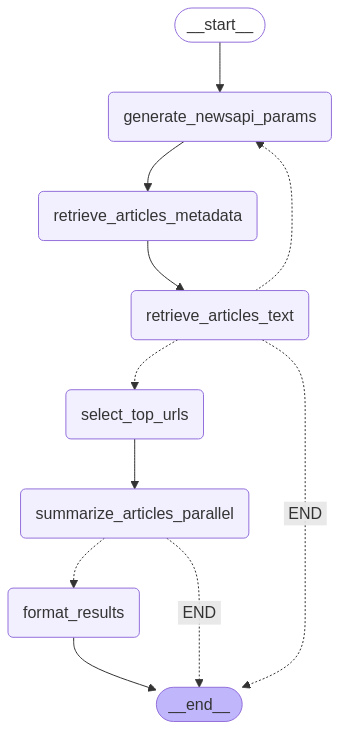

In [ ]:
display(
    IPImage(
        app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [ ]:
async def run_workflow(
    query: str, num_searches_remaining: int = 10, num_articles_tldr: int = 10
):
    """Run the LangGraph workflow and display results."""
    initial_state = {
        "news_query": query,
        "num_searches_remaining": num_searches_remaining,
        "newsapi_params": {},
        "past_searches": [],
        "articles_metadata": [],
        "scraped_urls": [],
        "num_articles_tldr": num_articles_tldr,
        "potential_articles": [],
        "tldr_articles": [],
        "formatted_results": "No articles with text found.",
    }
    try:
        result = await app.ainvoke(initial_state)

        return result["formatted_results"]
    except Exception as e:
        print(f"An error occurred: {str(e)}")
        return None


Ten kod definiuje asynchroniczną funkcję `run_workflow`, która uruchamia graf przepływu pracy (zdefiniowany wcześniej) i wyświetla wyniki.

*   **async def run\_workflow(query: str, num\_searches\_remaining: int = 10, num\_articles\_tldr: int = 10):** Definiuje asynchroniczną funkcję o nazwie `run_workflow`, która przyjmuje zapytanie użytkownika (`query`) jako argument obowiązkowy oraz liczbę pozostałych wyszukiwań (`num_searches_remaining`) i liczbę artykułów do streszczenia (`num_articles_tldr`) jako argumenty opcjonalne z wartościami domyślnymi 10.

*   **initial\_state = { ... }:** Tworzy słownik `initial_state`, który reprezentuje początkowy stan grafu przepływu pracy. Słownik ten zawiera wszystkie pola wymagane przez typ danych `GraphState` (zdefiniowany wcześniej), inicjalizowane wartościami domyślnymi.
    *   "news\_query": Zapytanie użytkownika.
    *   "num\_searches\_remaining": Liczba pozostałych wyszukiwań.
    *   "newsapi\_params": Pusty słownik dla parametrów News API.
    *   "past\_searches": Pusta lista poprzednich zapytań.
    *   "articles\_metadata": Pusta lista metadanych artykułów.
    *   "scraped\_urls": Pusta lista adresów URL, które zostały już przetworzone.
    *   "num\_articles\_tldr": Liczba artykułów do streszczenia.
    *   "potential\_articles": Pusta lista potencjalnych artykułów z pełną treścią.
    *   "tldr\_articles": Pusta lista skróconych artykułów.
    *   "formatted\_results": Początkowy komunikat informujący o braku znalezionych artykułów.

*   **try...except:** Blok try-except służy do obsługi potencjalnych błędów podczas uruchamiania grafu przepływu pracy.

    *   **result = await app.ainvoke(initial\_state):** Uruchamia graf przepływu pracy (`app`) z początkowym stanem (`initial_state`).  `await` oznacza, że funkcja czeka na zakończenie działania grafu przepływu pracy (ponieważ jest to operacja asynchroniczna). `ainvoke()` to metoda asynchronicznego wywołania grafu.
    *   **return result["formatted\_results"]:** Zwraca sformatowane wyniki (`formatted_results`) z obiektu `result` zwróconego przez graf przepływu pracy.

    *   **except Exception as e:** Obsługuje wszelkie wyjątki, które mogą wystąpić podczas uruchamiania grafu przepływu pracy.
        *   **print(f"An error occurred: {str(e)}"):** Wyświetla komunikat o błędzie na konsoli.
        *   **return None:** Zwraca `None` w przypadku wystąpienia błędu.

Podsumowując, funkcja ta uruchamia graf przepływu pracy z podanym zapytaniem użytkownika i zwraca sformatowane wyniki lub `None` w przypadku wystąpienia błędu.

In [ ]:
query = "what is the situation in Gaza?"
print(await run_workflow(query, num_articles_tldr=5))

Here are the top 4 articles based on search terms:
Gaza situation

Rubio discusses Gaza reconstruction with Saudi Arabia, future of ceasefire uncertain  
https://www.cbsnews.com/video/rubio-discusses-gaza-reconstruction-with-saudi-arabia-future-of-ceasefire-uncertain/  
* Secretary of State Marco Rubio met with Saudi Arabia's crown prince to discuss Middle East issues.  
* The talks focused on the reconstruction of Gaza following recent conflicts.  
* The future of the ceasefire between Israel and Hamas remains uncertain.  
* The situation in the region continues to evolve, impacting reconstruction efforts.  

Gaza ceasefire in peril as Palestinians struggle amid food shortages  
https://www.cbsnews.com/news/gaza-ceasefire-food-shortage-aid-cut-off-israel-hamas/  
* Israel is sending a delegation to Qatar to facilitate ceasefire negotiations.
* The ceasefire in Gaza is close to collapsing as both Israel and Hamas have stalled negotiations for a second phase.
* The first phase of the ce